In [ ]:
!pip install pennylane pennylane-lightning torch torchvision scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 69.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 104.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 11.4 MB/s eta 0:00:00


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving X_test_pca.npy to X_test_pca.npy
Saving y_test.npy to y_test.npy
Saving y_train.npy to y_train.npy
Saving X_train_pca.npy to X_train_pca.npy


In [ ]:
import numpy as np
import torch

X_train = np.load("X_train_pca.npy")
X_test = np.load("X_test_pca.npy")

y_train = np.load("y_train.npy")
y_test = np.load("y_test.npy")

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

print(X_train.shape)
print(X_test.shape)

torch.Size([2000, 4])
torch.Size([500, 4])


In [ ]:
import pennylane as qml
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

import matplotlib.pyplot as plt

In [ ]:
n_qubits = 4
n_layers = 4

dev = qml.device(
    "lightning.qubit",
    wires=n_qubits
)

In [ ]:
@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):

    for i in range(n_qubits):
        qml.RY(inputs[i], wires=i)

    for layer in range(n_layers):

        for q in range(n_qubits):
            qml.RY(
                weights[layer, q],
                wires=q
            )

        for q in range(n_qubits - 1):
            qml.CNOT(
                wires=[q, q+1]
            )

    return [
        qml.expval(
            qml.PauliZ(i)
        )
        for i in range(n_qubits)
    ]

In [ ]:
class EnhancedStaticVQC(nn.Module):

    def __init__(self):

        super().__init__()

        self.q_weights = nn.Parameter(
            0.01 * torch.randn(
                n_layers,
                n_qubits
            )
        )

        self.fc = nn.Linear(
            n_qubits,
            1
        )

    def forward(self, x):

        q_outputs = []

        for sample in x:

            q_out = quantum_circuit(
                sample,
                self.q_weights
            )

            q_outputs.append(
                torch.stack(q_out)
            )

        q_outputs = torch.stack(
            q_outputs
        )

        out = self.fc(
            q_outputs
        )

        return torch.sigmoid(
            out.squeeze()
        )

In [ ]:
model = EnhancedStaticVQC()

criterion = nn.BCELoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

In [ ]:
preds = model(
    X_train[:5]
)

print(preds)

tensor([0.4980, 0.5399, 0.5322, 0.5070, 0.4883], grad_fn=<SigmoidBackward0>)


In [ ]:
epochs = 30

loss_history = []
gradient_variance_history = []

for epoch in range(epochs):

    optimizer.zero_grad()

    preds = model(X_train)

    loss = criterion(
        preds,
        y_train
    )

    loss.backward()

    grad_values = []

    for p in model.parameters():
        grad_values.extend(
            p.grad.detach()
            .cpu()
            .numpy()
            .flatten()
        )

    grad_var = np.var(grad_values)

    gradient_variance_history.append(
        grad_var
    )

    optimizer.step()

    loss_history.append(
        loss.item()
    )

    print(
        f"Epoch {epoch+1:02d} | "
        f"Loss={loss.item():.4f} | "
        f"GradVar={grad_var:.8f}"
    )

Epoch 01 | Loss=0.7490 | GradVar=0.00727717
Epoch 02 | Loss=0.7405 | GradVar=0.00701437
Epoch 03 | Loss=0.7321 | GradVar=0.00675011
Epoch 04 | Loss=0.7239 | GradVar=0.00648772
Epoch 05 | Loss=0.7159 | GradVar=0.00623159
Epoch 06 | Loss=0.7080 | GradVar=0.00598611
Epoch 07 | Loss=0.7003 | GradVar=0.00575319
Epoch 08 | Loss=0.6926 | GradVar=0.00553164
Epoch 09 | Loss=0.6851 | GradVar=0.00531913
Epoch 10 | Loss=0.6777 | GradVar=0.00511383
Epoch 11 | Loss=0.6704 | GradVar=0.00491481
Epoch 12 | Loss=0.6633 | GradVar=0.00472174
Epoch 13 | Loss=0.6563 | GradVar=0.00453480
Epoch 14 | Loss=0.6495 | GradVar=0.00435440
Epoch 15 | Loss=0.6428 | GradVar=0.00418110
Epoch 16 | Loss=0.6363 | GradVar=0.00401543
Epoch 17 | Loss=0.6299 | GradVar=0.00385785
Epoch 18 | Loss=0.6237 | GradVar=0.00370870
Epoch 19 | Loss=0.6177 | GradVar=0.00356823
Epoch 20 | Loss=0.6118 | GradVar=0.00343655
Epoch 21 | Loss=0.6060 | GradVar=0.00331365
Epoch 22 | Loss=0.6004 | GradVar=0.00319930
Epoch 23 | Loss=0.5949 | GradVar

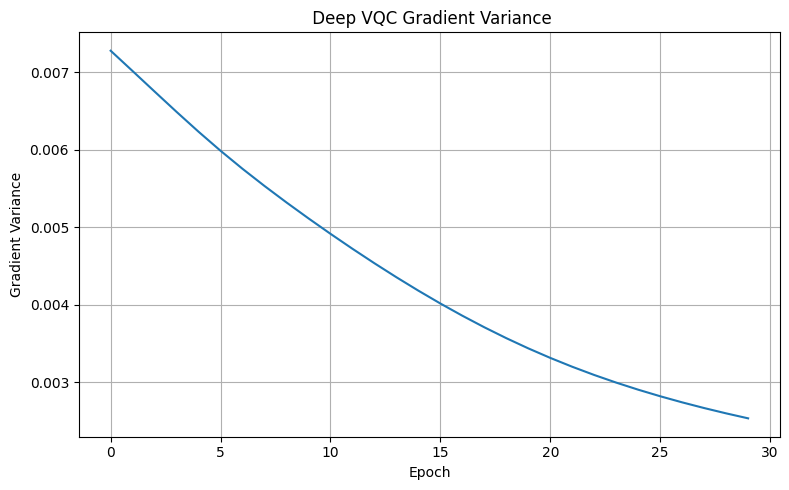

In [36]:
plt.figure(figsize=(8,5))

plt.plot(
    gradient_variance_history
)

plt.xlabel("Epoch")
plt.ylabel("Gradient Variance")
plt.title(" Deep VQC Gradient Variance")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "Fig_E2C_Gradient_Variance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

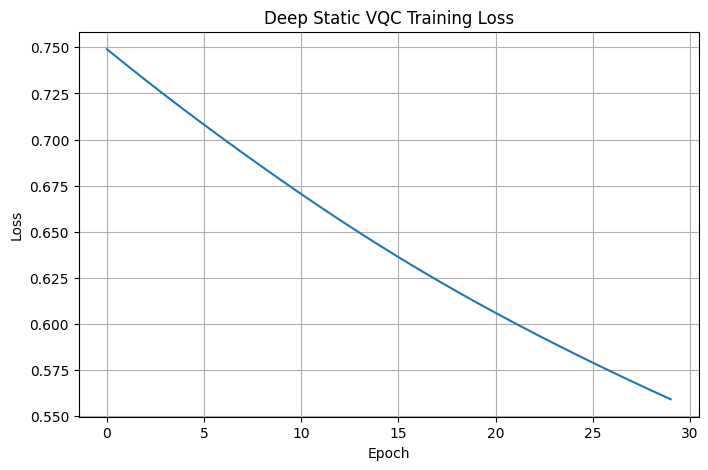

In [37]:
plt.figure(figsize=(8,5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Deep Static VQC Training Loss")

plt.grid(True)

plt.show()

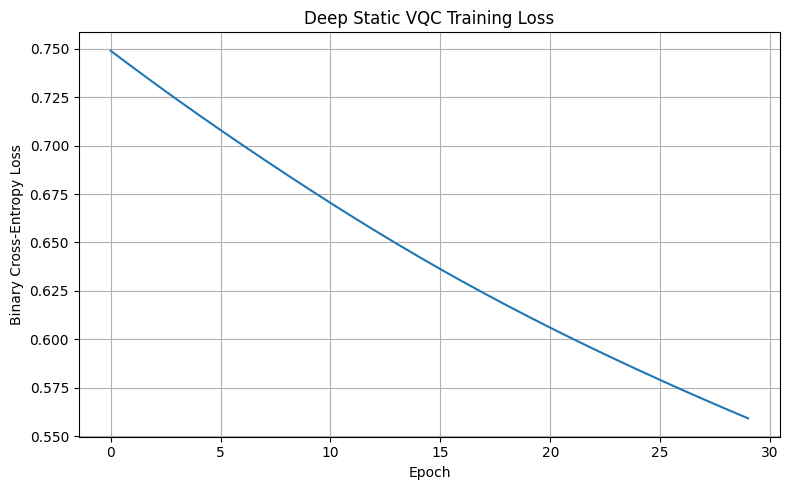

In [38]:
plt.figure(figsize=(8,5))
plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Deep Static VQC Training Loss")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "Fig_E2C_Training_Loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [39]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score

with torch.no_grad():

    probs = model(X_test)

preds = (probs > 0.5).int()

acc = accuracy_score(
    y_test.numpy(),
    preds.numpy()
)

f1 = f1_score(
    y_test.numpy(),
    preds.numpy()
)

print("Accuracy =", acc)
print("F1 Score =", f1)

Accuracy = 0.73
F1 Score = 0.8074179743223966


In [40]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test.numpy(),
    preds.numpy()
)

print(cm)

[[ 82 132]
 [  3 283]]


In [41]:
with torch.no_grad():
    probs = model(X_test)

print("Min:", probs.min().item())
print("Max:", probs.max().item())
print("Mean:", probs.mean().item())

Min: 0.28963354229927063
Max: 0.6737993359565735
Mean: 0.5783940553665161


In [42]:
with torch.no_grad():
    probs = model(X_test)

preds = (probs > 0.5).int()

In [43]:
cm = confusion_matrix(
    y_test.numpy(),
    preds.numpy()
)
print(cm)

[[ 82 132]
 [  3 283]]


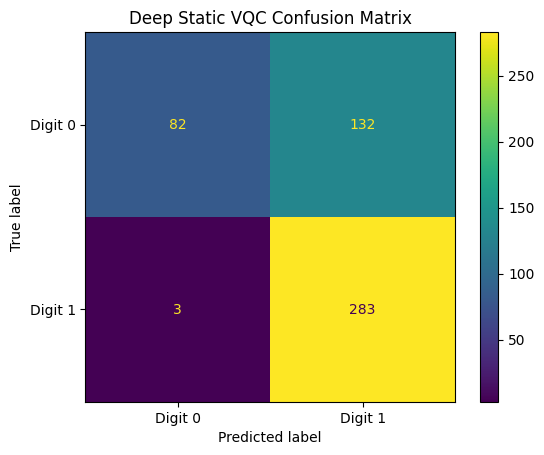

In [45]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test.numpy(),
    preds.numpy()
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Digit 0","Digit 1"]
)

disp.plot()

plt.title("Deep Static VQC Confusion Matrix")

plt.savefig(
    "Fig_E2C_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

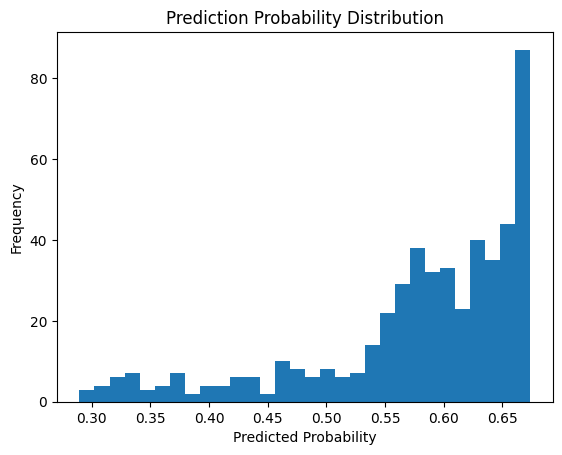

In [46]:
import matplotlib.pyplot as plt

plt.hist(probs.numpy(), bins=30)
plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Prediction Probability Distribution")
plt.show()

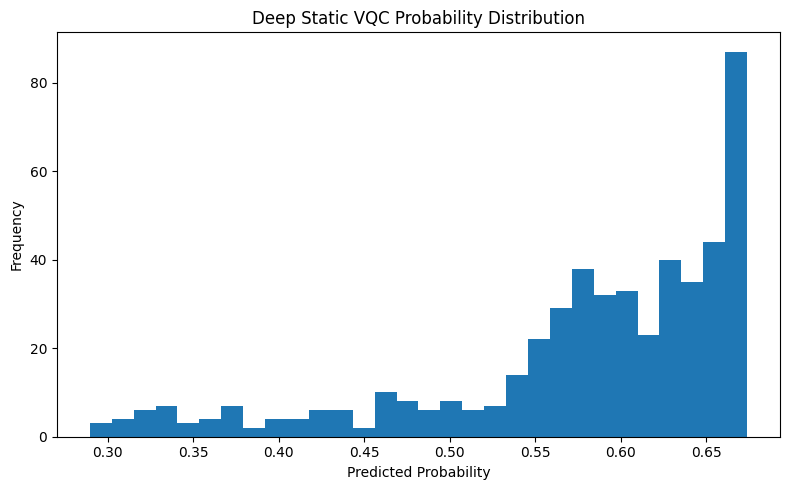

In [47]:
plt.figure(figsize=(8,5))

plt.hist(
    probs.numpy(),
    bins=30
)

plt.xlabel("Predicted Probability")
plt.ylabel("Frequency")
plt.title("Deep Static VQC Probability Distribution")

plt.tight_layout()

plt.savefig(
    "Fig_E2C_Probability_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
from sklearn.metrics import accuracy_score, f1_score

with torch.no_grad():
    probs = model(X_test)

for threshold in [0.3,0.4,0.5,0.6,0.7]:

    preds = (probs > threshold).int()

    acc = accuracy_score(
        y_test.numpy(),
        preds.numpy()
    )

    f1 = f1_score(
        y_test.numpy(),
        preds.numpy()
    )

    print(
        f"Threshold={threshold:.1f} | "
        f"Accuracy={acc:.4f} | "
        f"F1={f1:.4f}"
    )

Threshold=0.3 | Accuracy=0.5780 | F1=0.7305
Threshold=0.4 | Accuracy=0.6400 | F1=0.7594
Threshold=0.5 | Accuracy=0.7300 | F1=0.8074
Threshold=0.6 | Accuracy=0.7560 | F1=0.7732
Threshold=0.7 | Accuracy=0.4280 | F1=0.0000


In [51]:
from google.colab import files

files.download("Fig_E2C_Training_Loss.png")
files.download("Fig_E2C_Probability_Distribution.png")
files.download("Fig_E2C_Gradient_Variance.png")
files.download("Fig_E2C_Confusion_Matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Experiment E2B Summary
Experiment ID: E2

Model:
Enhanced Static VQC

Configuration:
- Dataset: MNIST (0 vs 1)
- Training Samples: 2000
- Testing Samples: 500
- PCA Components: 4
- Variance Retained: 56.06%
- Qubits: 4
- Variational Layers: 2
- Measurements: 4 (Z0,Z1,Z2,Z3)
- Classical Layer: Linear(4→1)

Results:
- Accuracy = 74.0%
- F1 Score = 0.8060
- Initial Loss = 0.7066
- Final Loss = 0.5600